Dataset loaded successfully.

--- Initial Data Exploration ---
First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980           

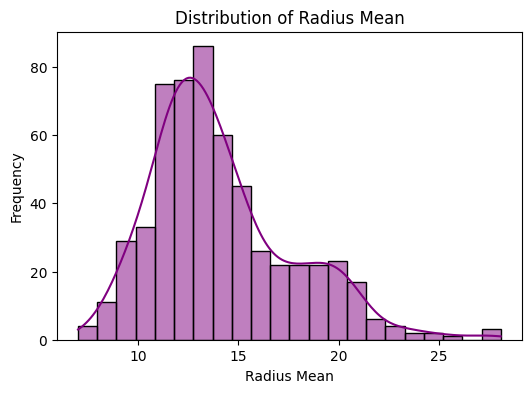

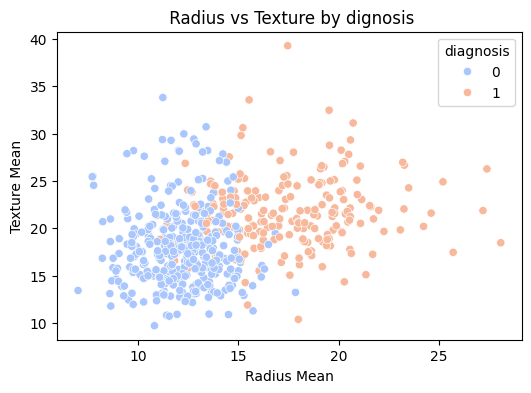

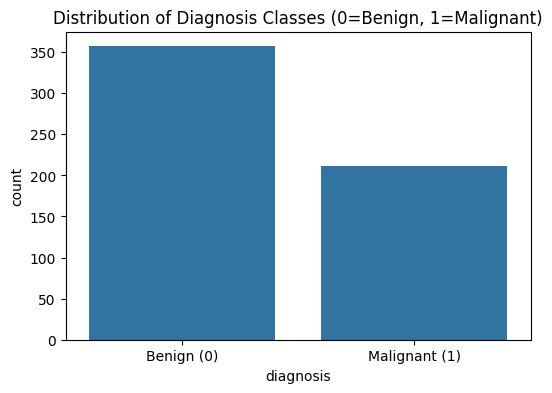

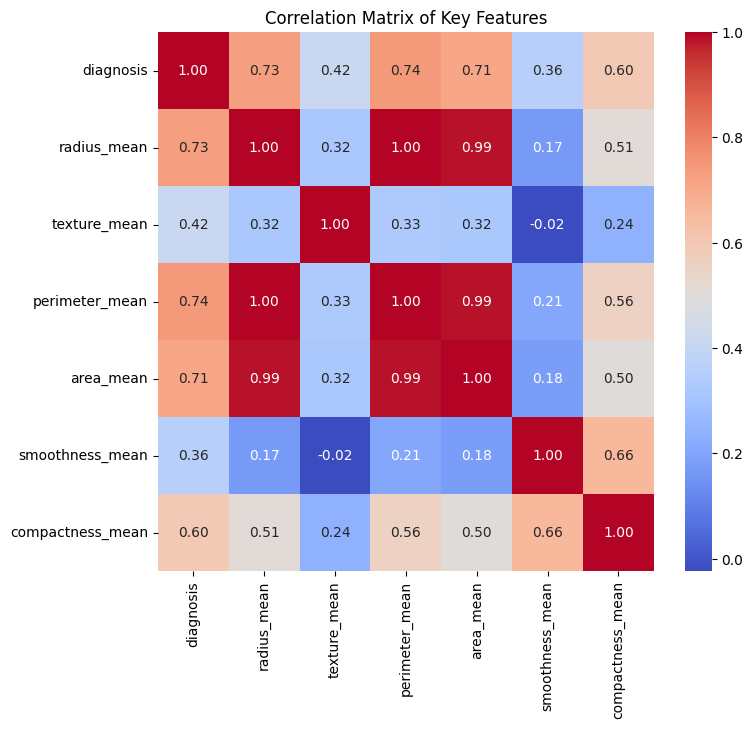


--- Model Building and Training ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3320 - loss: 0.8436 - val_accuracy: 0.8875 - val_loss: 0.4513
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9014 - loss: 0.4107 - val_accuracy: 0.9000 - val_loss: 0.2850
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9414 - loss: 0.2596 - val_accuracy: 0.9250 - val_loss: 0.2263
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9658 - loss: 0.1662 - val_accuracy: 0.9250 - val_loss: 0.2045
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9537 - loss: 0.1409 - val_accuracy: 0.9375 - val_loss: 0.1951
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9778 - loss: 0.0998 - val_accuracy: 0.9375 - val_loss: 0.1941
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9637 - loss: 0.1015 - val_accuracy: 0.9375 - val_loss: 0.1944
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9846 - loss: 0.0758 - val_accuracy: 0.9

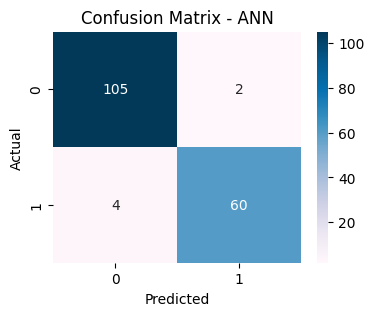

Model training complete.

--- Model Evaluation and Comparison ---

Performance Metrics Comparison (Sorted by ROC-AUC):
                              Accuracy  ROC-AUC  Precision  Recall  F1-Score
Logistic Regression             0.9766   0.9977     0.9839  0.9531    0.9683
Support Vector Machine (SVM)    0.9649   0.9971     1.0000  0.9062    0.9508
Gradient Boosting               0.9649   0.9968     1.0000  0.9062    0.9508
Random Forest                   0.9649   0.9943     1.0000  0.9062    0.9508


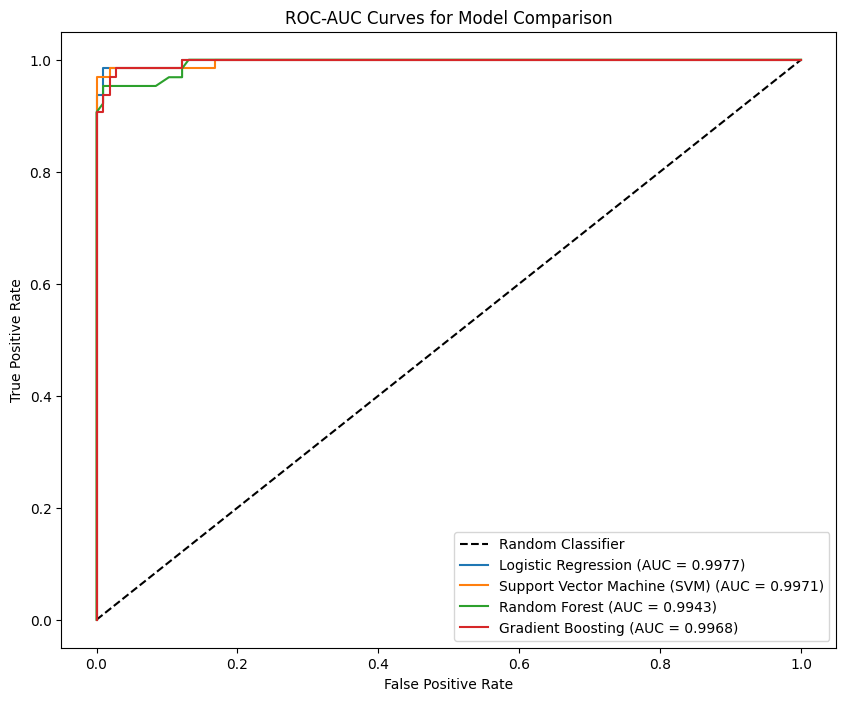


Best Performing Model: **Logistic Regression** (ROC-AUC: 0.9977)


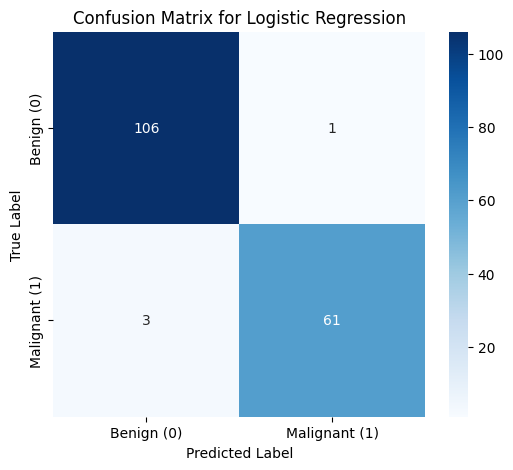


Multi-Domain Dataset Comparison 
Breast Cancer Logistic Regression Accuracy: 0.9766
Breast Cancer Random Forest Accuracy: 0.9649
Iris Logistic Regression Accuracy: 1.0000
Iris Random Forest Accuracy: 1.0000


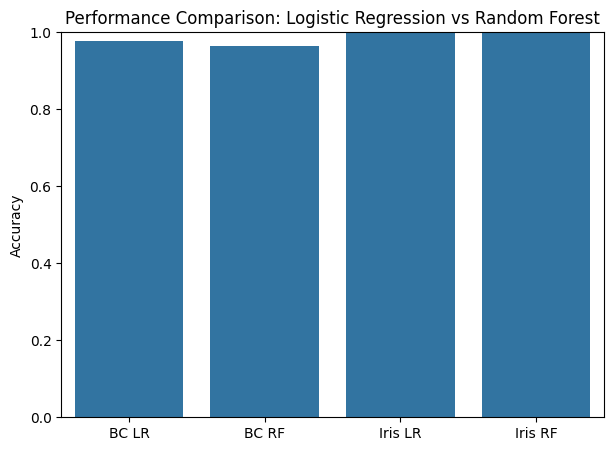


Comparison Complete.

Project Analysis Complete.


In [ ]:
#Project: Breast Cancer Wisconsin (Diagnostic) Dataset Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.datasets import load_iris

# Step 1: Data Collection and Initial Exploration

# Load the dataset
try:
    df = pd.read_csv('data.csv')
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Error: 'data.csv' not found. Please ensure the file is in the correct path.")

#Inspect structure, data types, and basic statistics

print("\n--- Initial Data Exploration ---")
print("First 5 rows:")
print(df.head())
print("\nData Information:")
df.info()
print("\nSummary Statistics:")
print(df.describe())
print("\nTarget value counts:")
print(df["diagnosis"].value_counts())

# Step 2: Data Cleaning and Preprocessing

print("\n--- Data Cleaning and Preprocessing ---")

# Drop unnecessary columns: 'id' and the unnamed column
# The 'Unnamed: 32' column contains all NaNs and can be dropped.

if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
if 'Unnamed: 32' in df.columns:
    df.drop('Unnamed: 32', axis=1, inplace=True)

# Check for missing values
print(f"Number of missing values before handling: {df.isnull().sum().sum()}")
#since there was no missing value we didn't need to clean it

# Encode the target variable 'diagnosis' (M=Malignant=1, B=Benign=0)
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])

print("\nTarget Variable Encoding Complete:")
print(df['diagnosis'].value_counts()) # 0: Benign, 1: Malignant

# Scaling will be added in step 4
# Feature Engineering
df["total_mean"] = df["radius_mean"] + df["texture_mean"] + df["perimeter_mean"] + df["area_mean"]
df["compact_ratio"] = df["compactness_mean"] / (df["radius_mean"] + 1e-6)
df["log_area"] = np.log(df["area_mean"] + 1)

print("\nFeature Engineering ")
print(df[["total_mean", "compact_ratio", "log_area"]].head())
# Step 3: Exploratory Data Analysis (EDA)

print("\n--- Exploratory Data Analysis (EDA) ---")

# Feature Distributions  Histogram
plt.figure(figsize=(6, 4))
sns.histplot(df['radius_mean'], kde=True, color='purple')
plt.title("Distribution of Radius Mean")
plt.xlabel("Radius Mean")
plt.ylabel("Frequency")
plt.show()

# Feature Relationships
plt.figure(figsize=(6, 4))
sns.scatterplot(x='radius_mean', y='texture_mean', data=df, hue='diagnosis', palette='coolwarm')
plt.title(" Radius vs Texture by dignosis")
plt.xlabel("Radius Mean")
plt.ylabel("Texture Mean")
plt.show()

# Class Balance Visualization
plt.figure(figsize=(6, 4))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribution of Diagnosis Classes (0=Benign, 1=Malignant)')
plt.xticks([0, 1], ['Benign (0)', 'Malignant (1)'])
plt.show()


# Correlation Heatmap (Focusing on a subset of features for clarity)
cols_for_corr = ['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean']
plt.figure(figsize=(8, 7))
sns.heatmap(df[cols_for_corr].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Matrix of Key Features')
plt.show()

# Step 4: Model Building

print("\n--- Model Building and Training ---")

# Define features (X) and target (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# Split data into training (70%) and testing (30%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Scaling features (Crucial for distance-based models like SVM and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, solver='liblinear'),
    "Support Vector Machine (SVM)": SVC(probability=True, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = {}

for name, model in models.items():
    if name in ["Logistic Regression", "Support Vector Machine (SVM)"]:
        # Train on scaled data
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        # Train on original data (tree-based models are scale-invariant)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    # Store evaluation metrics (Step 5)
    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'Model': model,
        'y_proba': y_proba
    }

# Build ANN model
ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Binary classification
])

# Compile model
ann.compile(optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy'])

# Early stopping to avoid overfitting
callback = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train model
history = ann.fit(X_train_scaled, y_train,
                  validation_split=0.2,
                  epochs=100,
                  batch_size=16,
                  callbacks=[callback],
                  verbose=1)

# Evaluate model
loss, accuracy = ann.evaluate(X_test_scaled, y_test)
print(f"\nANN Test Accuracy: {accuracy:.4f}")

# Predictions
y_pred_ann = (ann.predict(X_test_scaled) > 0.5).astype("int32")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ann)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt="d", cmap="PuBu")
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("Model training complete.")

# Step 5: Model Evaluation and Comparison

print("\n--- Model Evaluation and Comparison ---")

# 5.1 Display Performance Metrics
results_df = pd.DataFrame({k: {k2: v2 for k2, v2 in v.items() if k2 not in ['Model', 'y_proba']} for k, v in results.items()}).T
print("\nPerformance Metrics Comparison (Sorted by ROC-AUC):")
print(results_df.sort_values(by='ROC-AUC', ascending=False).round(4))

# 5.2 ROC-AUC Curve Visualization
plt.figure(figsize=(10, 8))
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')

best_auc = 0
best_model_name = ""

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    roc_auc = res['ROC-AUC']
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.4f})')

    if roc_auc > best_auc:
        best_auc = roc_auc
        best_model_name = name

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-AUC Curves for Model Comparison')
plt.legend(loc="lower right")
plt.show()

# 5.3 Confusion Matrix for the Best Performing Model (based on ROC-AUC)
print(f"\nBest Performing Model: **{best_model_name}** (ROC-AUC: {best_auc:.4f})")

best_model = results[best_model_name]['Model']
if best_model_name in ["Logistic Regression", "Support Vector Machine (SVM)"]:
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malignant (1)'],
            yticklabels=['Benign (0)', 'Malignant (1)'])
plt.title(f'Confusion Matrix for {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# Multi-Domain Dataset Comparison

print("\nMulti-Domain Dataset Comparison ")


# Breast Cancer

# Logistic Regression performance
bc_lr_acc = results["Logistic Regression"]["Accuracy"]

# Random Forest performance
bc_rf_acc = results["Random Forest"]["Accuracy"]

print(f"Breast Cancer Logistic Regression Accuracy: {bc_lr_acc:.4f}")
print(f"Breast Cancer Random Forest Accuracy: {bc_rf_acc:.4f}")


# Iris Dataset

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Convert to binary classification (Setosa vs Others)
y_iris = (y_iris == 0).astype(int)

# Split
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42, stratify=y_iris
)

# Scale
scaler_i = StandardScaler()
X_train_i_scaled = scaler_i.fit_transform(X_train_i)
X_test_i_scaled = scaler_i.transform(X_test_i)

# Initialize Iris models
iris_lr = LogisticRegression(random_state=42)
iris_rf = RandomForestClassifier(random_state=42, n_estimators=100)

# Train Logistic Regression
iris_lr.fit(X_train_i_scaled, y_train_i)
lr_pred_i = iris_lr.predict(X_test_i_scaled)
iris_lr_acc = accuracy_score(y_test_i, lr_pred_i)

# Train Random Forest (no scaling needed)
iris_rf.fit(X_train_i, y_train_i)
rf_pred_i = iris_rf.predict(X_test_i)
iris_rf_acc = accuracy_score(y_test_i, rf_pred_i)

print(f"Iris Logistic Regression Accuracy: {iris_lr_acc:.4f}")
print(f"Iris Random Forest Accuracy: {iris_rf_acc:.4f}")

# Visualization of Comparison


models = ["BC LR", "BC RF", "Iris LR", "Iris RF"]
acc_values = [bc_lr_acc, bc_rf_acc, iris_lr_acc, iris_rf_acc]

plt.figure(figsize=(7,5))
sns.barplot(x=models, y=acc_values)
plt.title("Performance Comparison: Logistic Regression vs Random Forest")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

print("\nComparison Complete.")

print("\nProject Analysis Complete.")
